In [2]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import utils

In [3]:
import scienceplots
plt.style.use(['science'])
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [4]:
#loading TNG-50 first

pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[0,0,10,1])
    brahma_control = control.control_sample_brahma(brahma_pop_Nstar10)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=5,zbin_width=0.3,min_N_values=5)
    


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=15)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


processing each merger redshifts for controls: 100%|██████████| 83/83 [00:02<00:00, 39.78it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:378: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 14
SM5_TNG


processing each merger redshifts for controls: 100%|██████████| 16/16 [00:00<00:00, 25.70it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:598: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 110
number of processable mergers with valid controls:
664
[32, 47, 53, 95, 97, 138, 97, 48]
SM5_LW10_TNG


...

Number of cases where a close enough match is not found within the acceptable tolerance: 328
number of processable mergers with valid controls:
795
[55, 67, 91, 100, 105, 149, 120, 69]
SM5_LW10_LOWSPIN_TNG


processing each merger redshifts for controls: 100%|██████████| 17/17 [00:00<00:00, 45.39it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 80
number of processable mergers with valid controls:
405
[28, 22, 29, 41, 44, 91, 59, 35]
SM5_LW10_LOWSPIN_RICH_TNG


processing each merger redshifts for controls: 100%|██████████| 18/18 [00:00<00:00, 115.22it/s]

Number of cases where a close enough match is not found within the acceptable tolerance: 49
number of processable mergers with valid controls:
127
[9, 7, 5, 15, 14, 25, 12, 17]
[55, 57, 54, 63, 65, 57, 70, 50]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 3.8]
Brahma common zbins: [0.  0.6 1.2 2.1 4.1 6.1]


In [5]:
print("Maximum z in each simulation")
for i,sim in enumerate(sim_names):
    sim_obj = sim_objs[sim]
    print(sim,np.max(sim_obj.z_merging_pop))

Maximum z in each simulation
SM5_TNG 8.012172948865935
SM5_LW10_TNG 8.012172948865935
SM5_DFD_3_TNG 8.012172948865935
SM5_LW10_DFD_3_TNG 7.005417045544533
SM5_LW10_LOWSPIN_TNG 9.00233985416247
SM5_LW10_LOWSPIN_RICH_TNG 9.996590466186332
TNG50 4.995933468164624


In [6]:
def merger_enhancement_calc(sim_obj,quantity,zbins,log=True,major_merger_mask=False):

    avg_quantity_enhancement = []
    std_quantity_enhancement = []

    for i in range(len(zbins)-1):
        merger_z_mask = (sim_obj.z_merging_pop >= zbins[i]) & (sim_obj.z_merging_pop < zbins[i+1])
        if major_merger_mask == True:
            merger_z_mask = merger_z_mask & sim_obj.major_major_merger_mask

        if quantity == 'Mgas':
            merging_pop_quantity = getattr(sim_obj,'MgasInRad')[merger_z_mask]
            control_pop_quantity = getattr(sim_obj,'Mgas_control_pop')[merger_z_mask]
            
           
        elif quantity == 'fgas':
            #merging_pop_quantity = getattr(sim_obj,'fgas_post_merger')[merger_z_mask]/getattr(sim_obj,'MstarInRad')[merger_z_mask]
            merging_pop_quantity = getattr(sim_obj,'fgas_progs')[merger_z_mask]/getattr(sim_obj,'MstarInRad')[merger_z_mask]
            control_pop_quantity = getattr(sim_obj,'fgas_control')[merger_z_mask]/getattr(sim_obj,'Mstar_control_pop')[merger_z_mask]
        
        elif quantity == 'StellarHalfmassRad':
            scale_factor_mergers = 1/(1+sim_obj.z_merging_pop[merger_z_mask])
            scale_factor_controls = 1/(1+sim_obj.z_control_pop[merger_z_mask])
            merging_pop_quantity = getattr(sim_obj,'StellarHalfmassRad_merging_pop')[merger_z_mask]
            control_pop_quantity = getattr(sim_obj,'StellarHalfmassRad_control_pop')[merger_z_mask]
            merging_pop_quantity = merging_pop_quantity * scale_factor_mergers
            control_pop_quantity = control_pop_quantity * scale_factor_controls        
            
        else:
            merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[merger_z_mask]
            control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[merger_z_mask]

        if log == True:
            quantity_log_enhancement = []
            for i in range(len(control_pop_quantity)):
                if control_pop_quantity[i]>0 and merging_pop_quantity[i]>0:
                    quantity_log_enhancement.append(np.log10(merging_pop_quantity[i]/control_pop_quantity[i]))
            avg_quantity_enhancement.append(np.mean(quantity_log_enhancement))
            #avg_quantity_enhancement.append(np.median(quantity_log_enhancement))
            std_quantity_enhancement.append(np.std(quantity_log_enhancement)/np.sqrt(len(quantity_log_enhancement)))
            #std_quantity_enhancement.append(stats.sem(quantity_log_enhancement))
        else:
            quantity_enhancement = merging_pop_quantity - control_pop_quantity
            avg_quantity_enhancement.append(np.mean(quantity_enhancement))
            #avg_quantity_enhancement.append(np.median(quantity_log_enhancement))
            std_quantity_enhancement.append(np.std(quantity_enhancement)/np.sqrt(len(quantity_enhancement)))
            #std_quantity_enhancement.append(stats.sem(quantity_enhancement))

    avg_quantity_enhancement = np.array(avg_quantity_enhancement)
    std_quantity_enhancement = np.array(std_quantity_enhancement)

    return avg_quantity_enhancement,std_quantity_enhancement

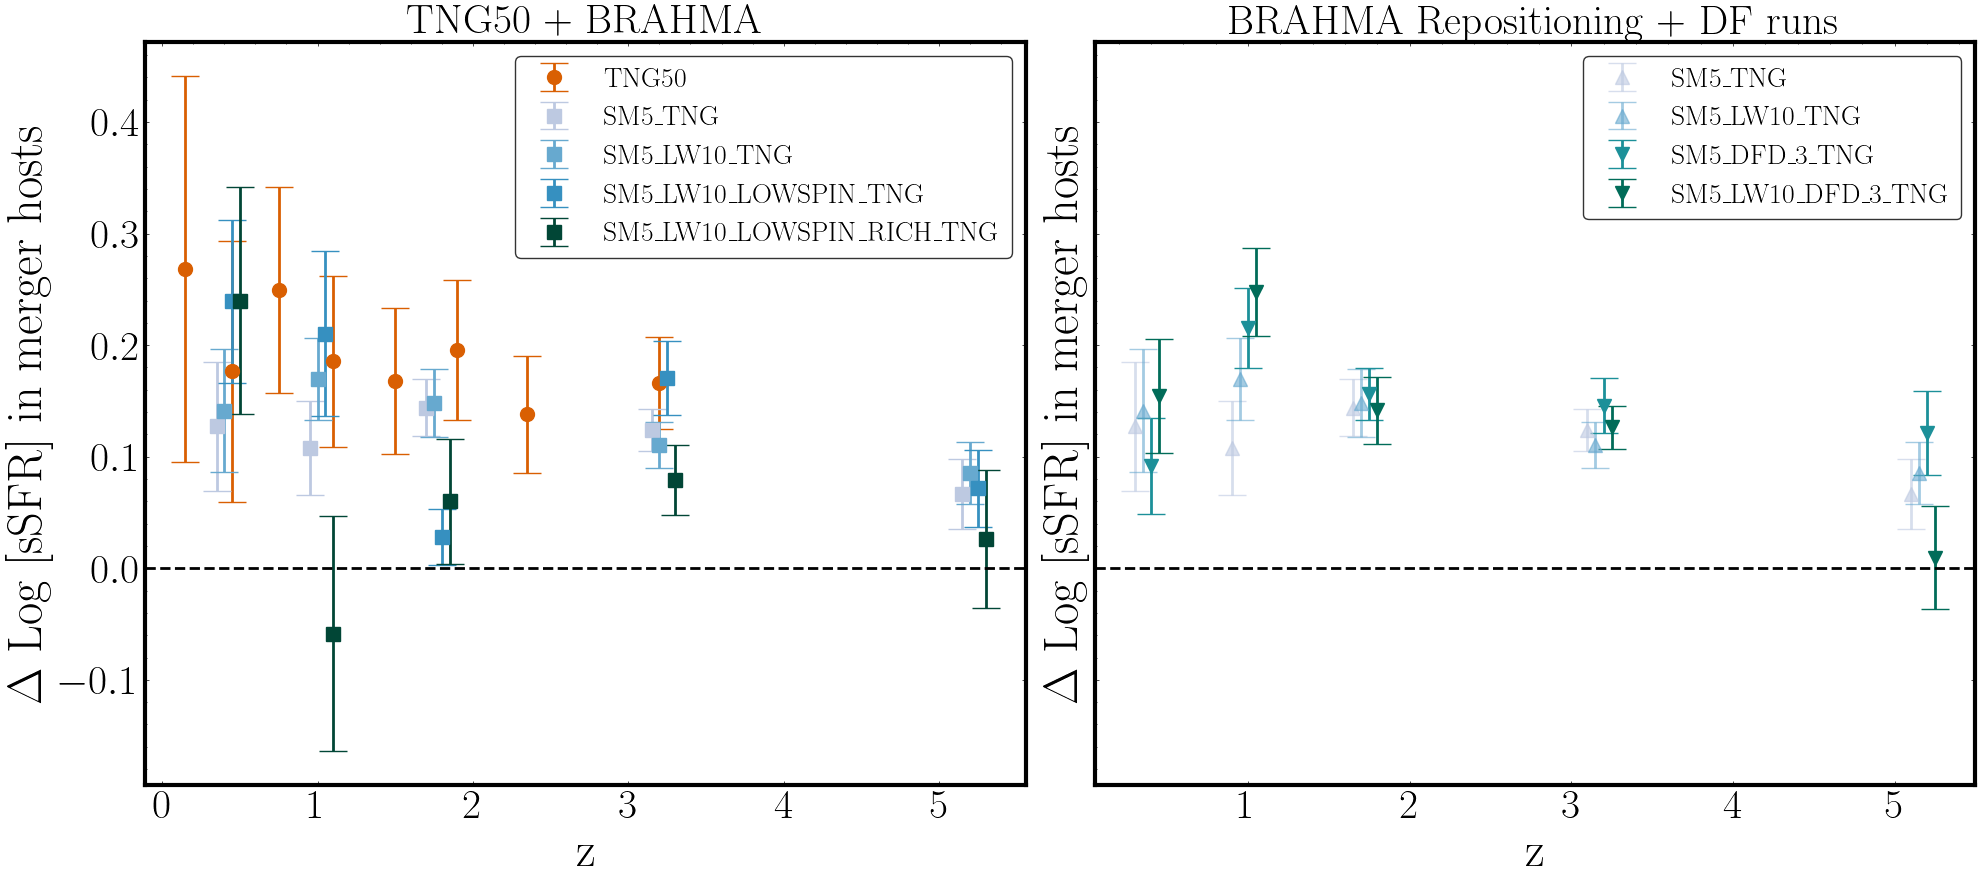

In [7]:
# sSFR Enhancement plots: TNG50 + BRAHMA (left) vs Repositioning + DFD (right)

# Define simulation groups
tng_sims = ['TNG50']
brahma_non_dfd = ['SM5_TNG', 'SM5_LW10_TNG', 'SM5_LW10_LOWSPIN_TNG', 'SM5_LW10_LOWSPIN_RICH_TNG']
brahma_dfd = ['SM5_DFD_3_TNG', 'SM5_LW10_DFD_3_TNG']

# Set up plot style
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=20,bold=True)

# Create figure with 1x2 subplots
fig, ax = plt.subplots(1, 2, figsize=(20,9),sharey=True)

# Left subplot: TNG50 + all BRAHMA non-DFD sims
z_offset_left = 0.05
i = 0
# Plot TNG50
avg_sSFR, std_sSFR = merger_enhancement_calc(sim_objs['TNG50'], 'sSFR', sim_zbins_list['TNG50'], log=True)
z_mid = sim_zbins_list['TNG50'][:-1] + np.diff(sim_zbins_list['TNG50']) / 2
ax[0].errorbar(z_mid, avg_sSFR, yerr=std_sSFR, fmt='o', capsize=10, markersize=10, 
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)

# Plot BRAHMA non-DFD sims
for j, sim in enumerate(brahma_non_dfd):
    avg_sSFR, std_sSFR = merger_enhancement_calc(sim_objs[sim], 'sSFR', sim_zbins_list[sim], log=True)
    z_mid = sim_zbins_list[sim][:-1] + np.diff(sim_zbins_list[sim]) / 2
    ax[0].errorbar(z_mid + z_offset_left * (j + 1), avg_sSFR, yerr=std_sSFR, fmt='s', capsize=10, 
                   markersize=10, label=sim, color=sim_colors[sim], alpha=1, linewidth=2)

ax[0].axhline(0, ls='--', color='black', linewidth=2)
ax[0].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[0].set_xlabel('z')
ax[0].set_title('TNG50 + BRAHMA')
ax[0].legend(frameon=True, edgecolor='black')
#ax[0].grid(True, alpha=0.3)

# Right subplot: Non-DFD BRAHMA vs DFD BRAHMA
z_offset_right = 0.05
# Plot non-DFD sims
brahma_non_dfd = ['SM5_TNG', 'SM5_LW10_TNG']
for j, sim in enumerate(brahma_non_dfd):
    avg_sSFR, std_sSFR = merger_enhancement_calc(sim_objs[sim], 'sSFR', sim_zbins_list[sim], log=True)
    z_mid = sim_zbins_list[sim][:-1] + np.diff(sim_zbins_list[sim]) / 2
    ax[1].errorbar(z_mid + z_offset_right * j, avg_sSFR, yerr=std_sSFR, fmt='^', capsize=10, 
                   markersize=10, label=sim , color=sim_colors[sim], alpha=0.6, linewidth=2)

# Plot DFD sims
for j, sim in enumerate(brahma_dfd):
    avg_sSFR, std_sSFR = merger_enhancement_calc(sim_objs[sim], 'sSFR', sim_zbins_list[sim], log=True)
    z_mid = sim_zbins_list[sim][:-1] + np.diff(sim_zbins_list[sim]) / 2
    ax[1].errorbar(z_mid + z_offset_right * (j + len(brahma_non_dfd)), avg_sSFR, yerr=std_sSFR, fmt='v', 
                   capsize=10, markersize=10, label=sim, color=sim_colors[sim], alpha=1, linewidth=2)

ax[1].axhline(0, ls='--', color='black', linewidth=2)
ax[1].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[1].set_xlabel('z')
ax[1].set_title('BRAHMA Repositioning + DF runs ')
ax[1].legend(frameon=True, edgecolor='black')
#ax[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("../../figures/sSFR_enhancement_TNG_and_BRAHMA.pdf")
plt.show()


#### Summary statistics of sSFR in mergers vs controls across simulations

In [8]:
summary_enhancement = {}

for sim in sim_names:
    sim_obj = sim_objs[sim]
    sSFR_merging = sim_objs[sim].sSFR_merging_pop
    sSFR_control = sim_objs[sim].sSFR_control_pop
    
    
    # Calculate log enhancement for valid pairs
    log_enhancement = []
    for i in range(len(sSFR_merging)):
        if sSFR_control[i] > 0 and sSFR_merging[i] > 0:
            log_enhancement.append(np.log10(sSFR_merging[i] / sSFR_control[i]))
    
    log_enhancement = np.array(log_enhancement)
    mean_enh = np.mean(log_enhancement)
    std_enh = np.std(log_enhancement)
    sem_enh = std_enh / np.sqrt(len(log_enhancement))  # Standard error of mean
    n_valid = len(log_enhancement)
    
    summary_enhancement[sim] = {
        'mean': mean_enh,
        'std': std_enh,
        'sem': sem_enh,
        'N': n_valid
    }
    
    print(f"{sim:^35} {mean_enh:+.4f}          {sem_enh:.4f}           {n_valid:^10d}")

    

              SM5_TNG               +0.1231          0.0154              644    
           SM5_LW10_TNG             +0.1344          0.0149              523    
           SM5_DFD_3_TNG            +0.1561          0.0148              851    
        SM5_LW10_DFD_3_TNG          +0.1588          0.0165              765    
       SM5_LW10_LOWSPIN_TNG         +0.1220          0.0201              400    
     SM5_LW10_LOWSPIN_RICH_TNG      +0.0621          0.0305              126    
               TNG50                +0.1887          0.0308              469    


In [9]:
sim_logMstar = {}
for sim in sim_names:
    Mstar_merging = sim_objs[sim].Mstar_merging_pop
    z_bins = sim_zbins_list[sim]
    Mstar_avg = []
    Mstar_error = []
    for i in range(len(z_bins)-1):
        z_low = z_bins[i]
        z_high = z_bins[i+1]
        z_mask = (sim_objs[sim].z_merging_pop >= z_low) & (sim_objs[sim].z_merging_pop < z_high)
        Mstar_in_bin = np.log10(Mstar_merging[z_mask])
        Mstar_avg.append(np.mean(Mstar_in_bin))
        Mstar_error.append(stats.sem(Mstar_in_bin))
    Mstar_avg = np.array(Mstar_avg)
    Mstar_error = np.array(Mstar_error)
    sim_logMstar[sim]={
        'mean': Mstar_avg,
        'sem': Mstar_error  
    }


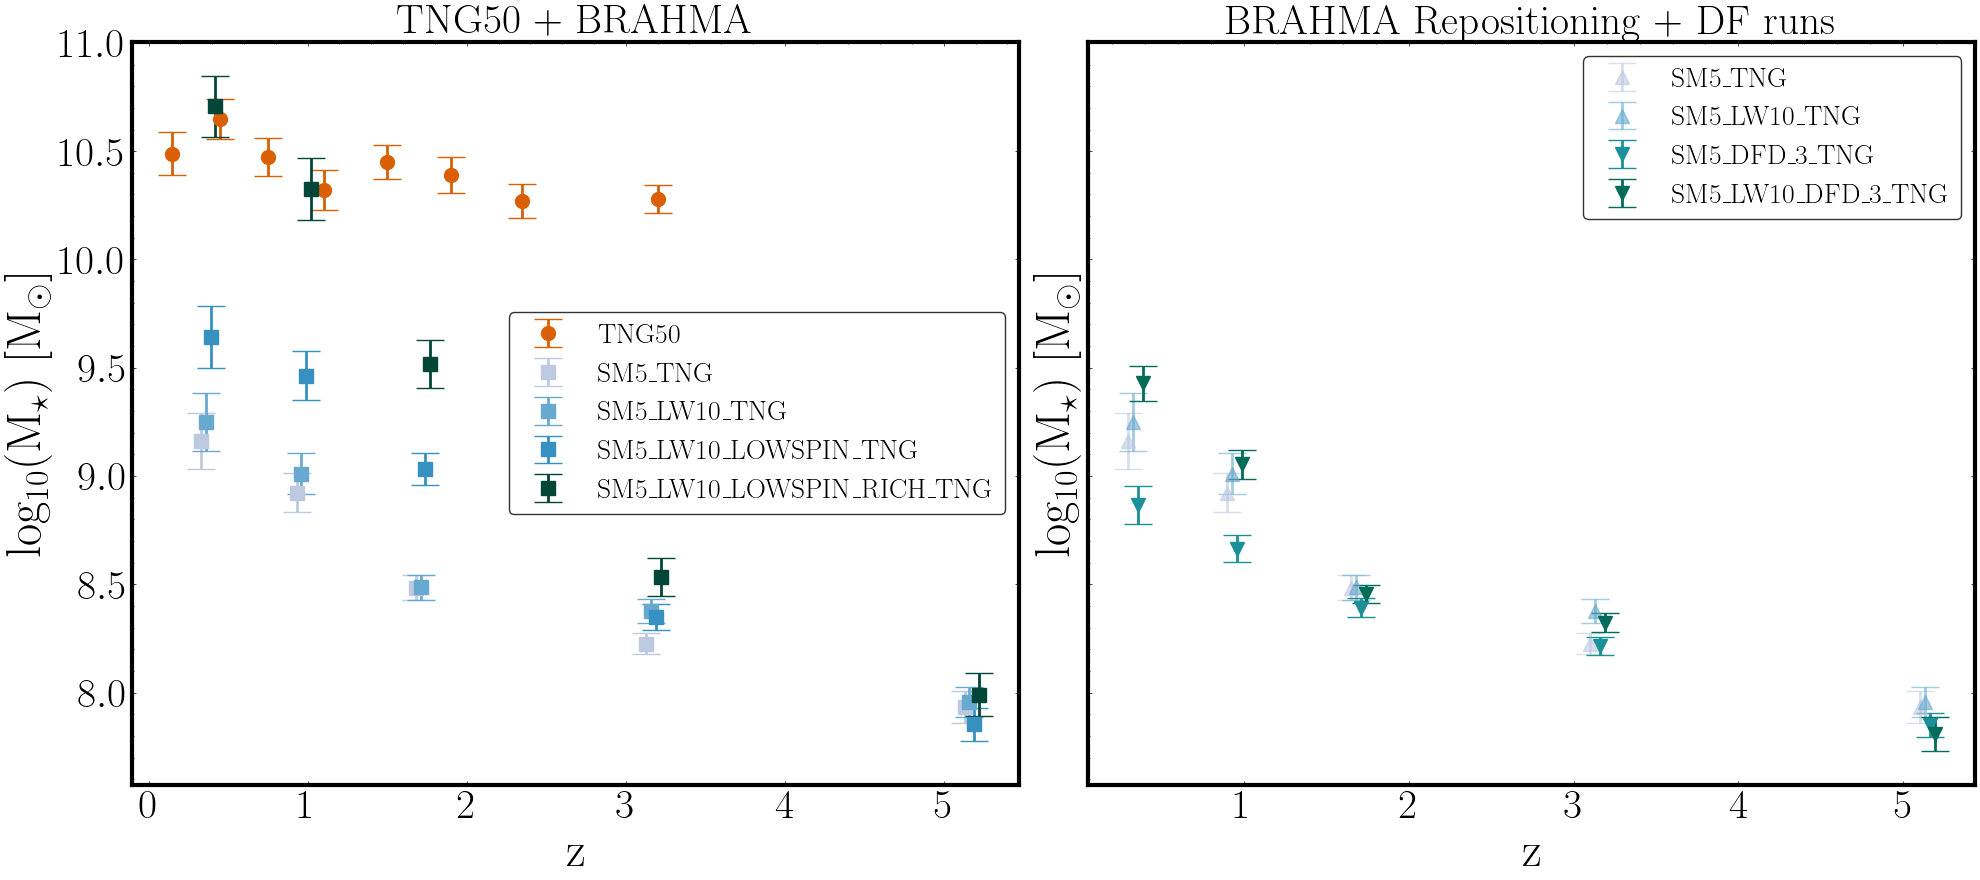

In [10]:

# Plot sim_logMstar with two subplots: TNG50 + BRAHMA (left) vs Repositioning + DF (right)
hostplot.set_plot_style(spinewidth=3, linewidth=3, titlesize=30, labelsize=35, xlabelsize=30, ylabelsize=30, legendsize=20, bold=True)

# Define simulation groups for Mstar plotting
tng_sims_mstar = ['TNG50']
brahma_non_dfd_mstar = ['SM5_TNG', 'SM5_LW10_TNG', 'SM5_LW10_LOWSPIN_TNG', 'SM5_LW10_LOWSPIN_RICH_TNG']
brahma_dfd_mstar = ['SM5_DFD_3_TNG', 'SM5_LW10_DFD_3_TNG']

fig, ax = plt.subplots(1, 2, figsize=(20, 9), sharey=True)

# Left subplot: TNG50 + all BRAHMA non-DFD sims
z_offset_left = 0.03
i = 0

# Plot TNG50
zbins = sim_zbins_list['TNG50']
z_mid = (zbins[:-1] + zbins[1:]) / 2
mean_Mstar = sim_logMstar['TNG50']['mean']
sem_Mstar = sim_logMstar['TNG50']['sem']
ax[0].errorbar(z_mid, mean_Mstar, yerr=sem_Mstar, fmt='o', capsize=10, markersize=10,
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)

# Plot BRAHMA non-DFD sims
for j, sim in enumerate(brahma_non_dfd_mstar):
    zbins = sim_zbins_list[sim]
    z_mid = (zbins[:-1] + zbins[1:]) / 2
    mean_Mstar = sim_logMstar[sim]['mean']
    sem_Mstar = sim_logMstar[sim]['sem']
    z_plot = z_mid + z_offset_left * (j + 1)
    ax[0].errorbar(z_plot, mean_Mstar, yerr=sem_Mstar, fmt='s', capsize=10, markersize=10,
                   label=sim, color=sim_colors[sim], alpha=1, linewidth=2)

ax[0].set_ylabel('log$_{10}$(M$_\\star$) [M$_\\odot$]')
ax[0].set_xlabel('z')
ax[0].set_title('TNG50 + BRAHMA')
ax[0].legend(frameon=True, edgecolor='black')

# Right subplot: Non-DFD BRAHMA vs DFD BRAHMA
z_offset_right = 0.03

# Plot non-DFD sims
brahma_non_dfd_subset = ['SM5_TNG', 'SM5_LW10_TNG']
for j, sim in enumerate(brahma_non_dfd_subset):
    zbins = sim_zbins_list[sim]
    z_mid = (zbins[:-1] + zbins[1:]) / 2
    mean_Mstar = sim_logMstar[sim]['mean']
    sem_Mstar = sim_logMstar[sim]['sem']
    z_plot = z_mid + z_offset_right * j
    ax[1].errorbar(z_plot, mean_Mstar, yerr=sem_Mstar, fmt='^', capsize=10, markersize=10,
                   label=sim, color=sim_colors[sim], alpha=0.6, linewidth=2)

# Plot DFD sims
for j, sim in enumerate(brahma_dfd_mstar):
    zbins = sim_zbins_list[sim]
    z_mid = (zbins[:-1] + zbins[1:]) / 2
    mean_Mstar = sim_logMstar[sim]['mean']
    sem_Mstar = sim_logMstar[sim]['sem']
    z_plot = z_mid + z_offset_right * (j + len(brahma_non_dfd_subset))
    ax[1].errorbar(z_plot, mean_Mstar, yerr=sem_Mstar, fmt='v', capsize=10, markersize=10,
                   label=sim, color=sim_colors[sim], alpha=1, linewidth=2)

ax[1].set_ylabel('log$_{10}$(M$_\\star$) [M$_\\odot$]')
ax[1].set_xlabel('z')
ax[1].set_title('BRAHMA Repositioning + DF runs')
ax[1].legend(frameon=True, edgecolor='black')

fig.tight_layout()
plt.show()


/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/utils.py:315: RuntimeWarning: divide by zero encountered in divide
  quantity_enhancement = merging_pop_quantity / control_pop_quantity
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/utils.py:319: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(quantity_enhancement)


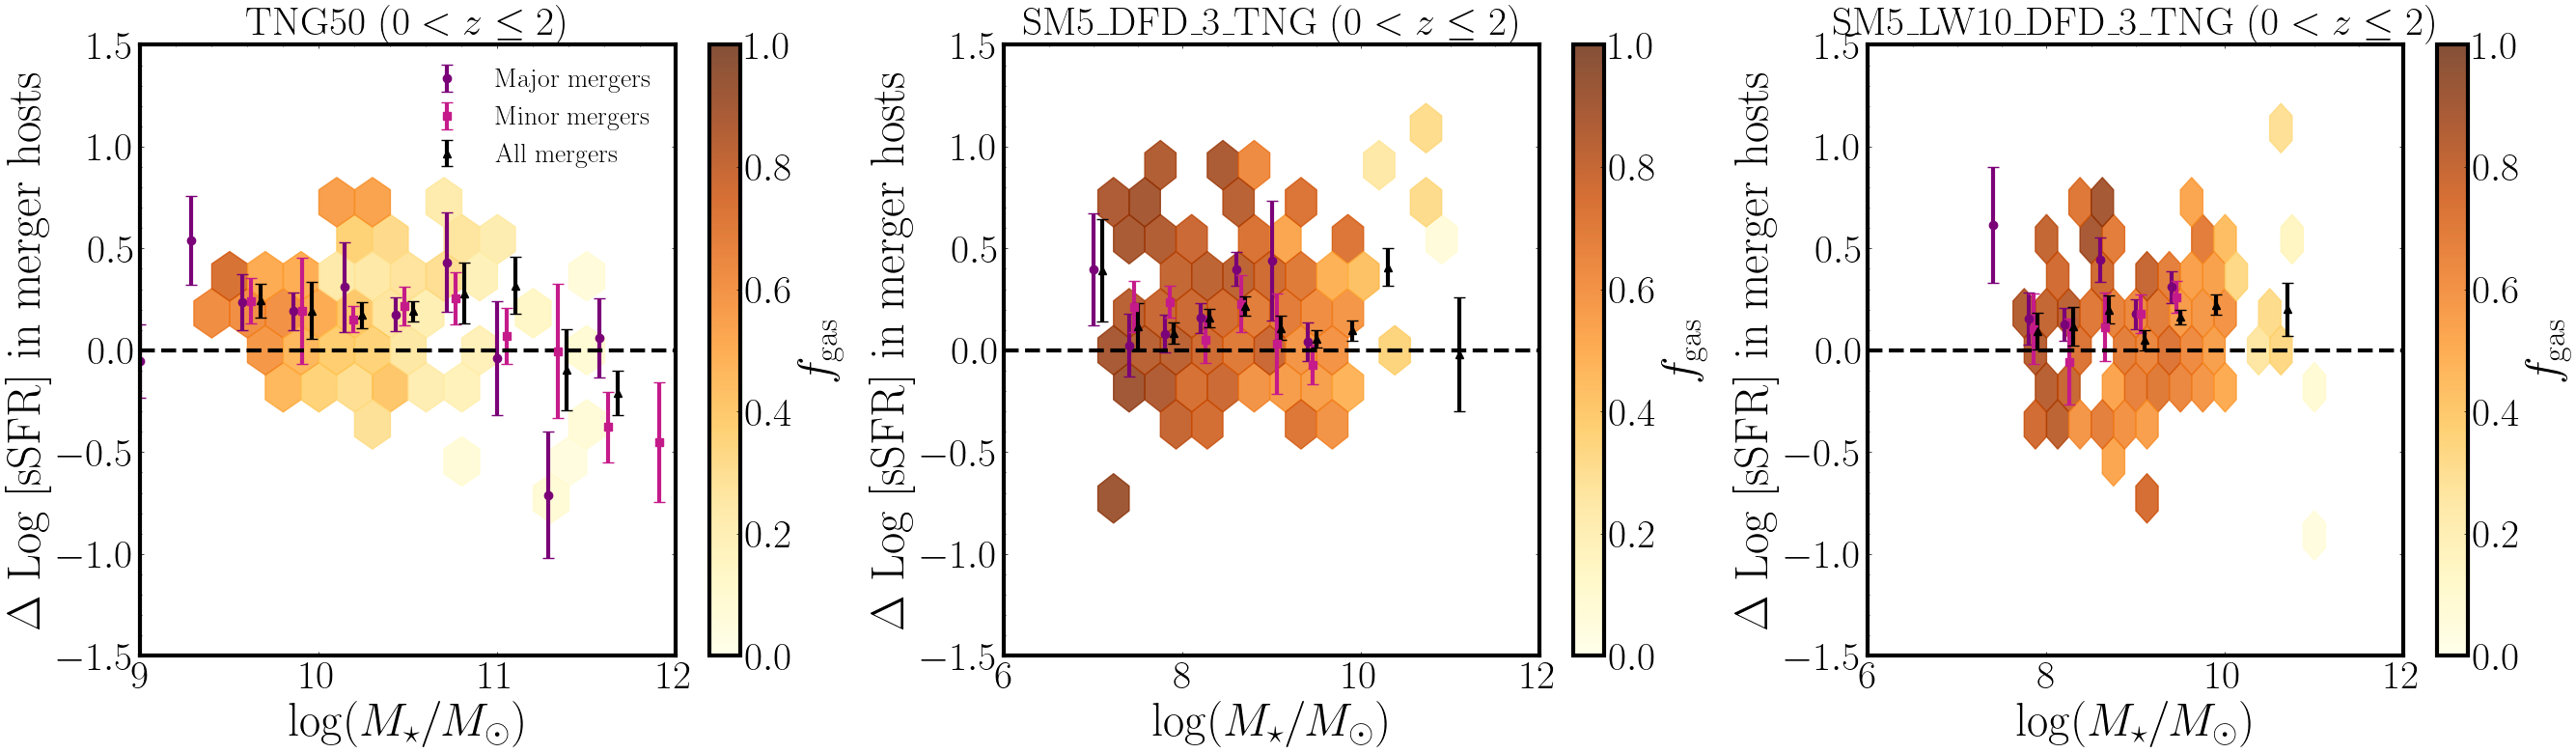

In [11]:
fig,ax = plt.subplots(1,3,figsize=(27,8))

log_Mstar_bins = np.linspace(8,12,15)

sim='TNG50'
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=10)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[0] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[0], sim_objs[sim], quantity='sSFR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=8, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[0].set_xlim(9,12)
ax[0].set_ylim(-1.5,1.5)
ax[0].legend()
ax[0].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_DFD_3_TNG'
log_Mstar_bins = np.arange(6,12,0.4)
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=10)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[1] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[1], sim_objs[sim], quantity='sSFR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=13, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[1].set_xlim(6,12)
ax[1].set_ylim(-1.5,1.5)
#ax[1].legend()
ax[1].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_LW10_DFD_3_TNG'
log_Mstar_bins = np.arange(6,12,0.4)
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=5)
avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=10)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=20)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[2] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[2], sim_objs[sim], quantity='sSFR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=11, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[2].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[2].axhline(0,ls='--',color='black')
ax[2].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[2].set_xlim(6,12)
ax[2].set_ylim(-1.5,1.5)
#ax1].legend()
ax[2].set_title(f'{sim} ($0<z\leq2$)')

fig.tight_layout()
fig.savefig('../../figures/sSFR_vs_Mstar_for_TNG50_and_Brahma_DF.pdf')

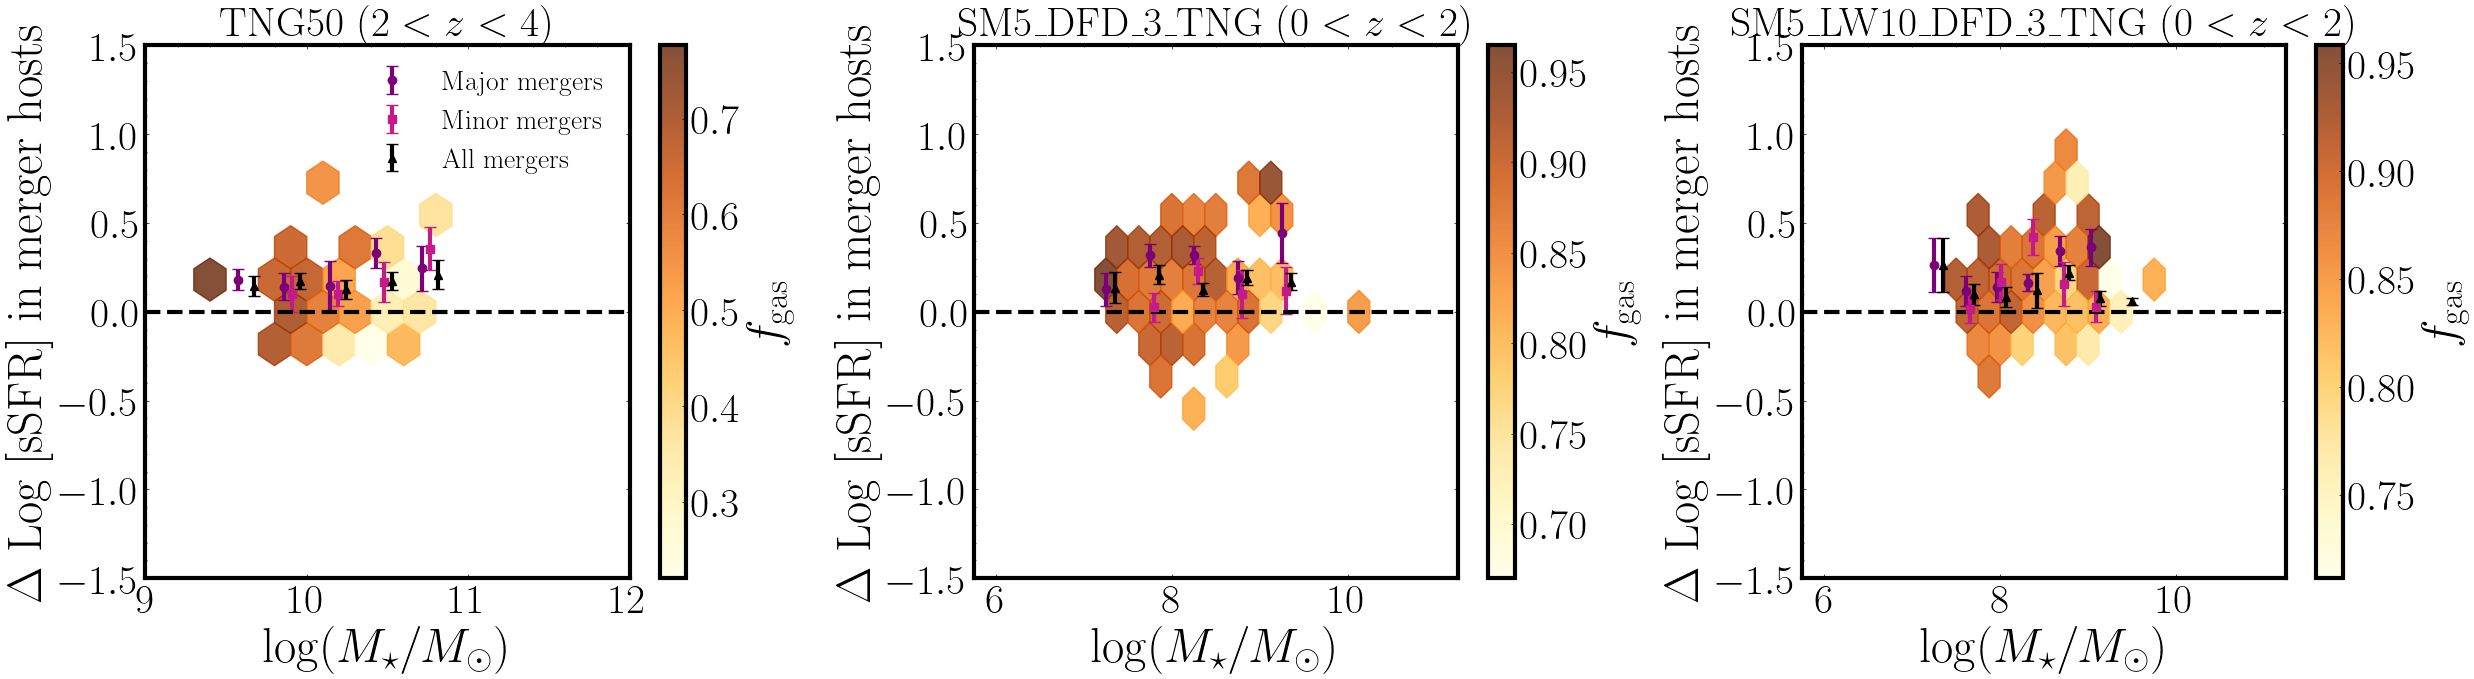

In [11]:
fig,ax = plt.subplots(1,3,figsize=(25,7))

log_Mstar_bins = np.linspace(8,12,15)

sim='TNG50'
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,major_merger_flag=True,min_N=4)
avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,min_N=10)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[0] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[0], sim_objs[sim], quantity='sSFR', zlow=2, zupper=4,
    gridsize=20, cmap='YlOrBr', xmin=8, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas'
)

ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[0].set_xlim(9,12)
ax[0].set_ylim(-1.5,1.5)
ax[0].legend()
ax[0].set_title(f'{sim} ($2<z<4)$')

sim='SM5_DFD_3_TNG'
log_Mstar_bins = np.arange(6,11,0.5)
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,major_merger_flag=True,min_N=4)
avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,min_N=10)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[1] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[1], sim_objs[sim], quantity='sSFR', zlow=2, zupper=4,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=11, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas'
)

ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
#ax[1].set_xlim(9,12)
ax[1].set_ylim(-1.5,1.5)
#ax[1].legend()
ax[1].set_title(f'{sim} ($0<z<2)$')

sim='SM5_LW10_DFD_3_TNG'
log_Mstar_bins = np.linspace(6,11,15)
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,major_merger_flag=True,min_N=4)
avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=2,zupper=4,log=True,min_N=10)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[2] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[2], sim_objs[sim], quantity='sSFR', zlow=2, zupper=4,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=11, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas'
)

ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[2].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[2].axhline(0,ls='--',color='black')
ax[2].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
#ax[1].set_xlim(9,12)
ax[2].set_ylim(-1.5,1.5)
#ax1].legend()
ax[2].set_title(f'{sim} ($0<z<2$)')


fig.tight_layout()

In [22]:
def find_avg_sSFR_above_Mstar_in_z_interval(sim_obj, z1, z2, Mstar_cutoff):
    # 1. Apply Redshift Mask
    z_mask = (sim_obj.z_merging_pop >= z1) & (sim_obj.z_merging_pop < z2)
    
    # 2. Extract sSFR and Mstar
    Mstar_merging = np.log10(sim_obj.Mstar_merging_pop)
    sSFR_m = sim_obj.sSFR_merging_pop
    sSFR_c = sim_obj.sSFR_control_pop

    # 3. Handle Zero/Negative sSFR (Avoid log10(0))
    # Option A: Mask out zeros (Recommended if you only care about star-forming galaxies)
    # Option B: Add a tiny floor (e.g., 1e-14) if you want to keep quenched galaxies
    valid_sSFR = (sSFR_m > 0) & (sSFR_c > 0)
    
    # 4. Combine Masks
    combined_mask = z_mask & valid_sSFR
    
    # 5. Define Mass Masks within the valid subset
    Mstar_mask_above = (Mstar_merging >= Mstar_cutoff) & combined_mask
    Mstar_mask_below = (Mstar_merging < Mstar_cutoff) & combined_mask 

    # 6. Calculate enhancements (Difference of logs)
    # We only slice using the combined masks to ensure we never hit a zero
    enhancement_above = np.log10(sSFR_m[Mstar_mask_above]) - np.log10(sSFR_c[Mstar_mask_above])
    enhancement_below = np.log10(sSFR_m[Mstar_mask_below]) - np.log10(sSFR_c[Mstar_mask_below])
    
    # 7. Check if arrays are empty to avoid median of empty slice warning
    def safe_median(data):
        return np.median(data) if len(data) > 0 else np.nan

    print(f"Count above cutoff: {len(enhancement_above)}")
    print(f"Enhancement above the stellar mass threshold:{safe_median(enhancement_above):.2f}")
    print(f"Enhancement below the stellar mass threshold:{safe_median(enhancement_below):.2f}")
    return safe_median(enhancement_above), safe_median(enhancement_below)


In [36]:
find_avg_sSFR_above_Mstar_in_z_interval(sim_objs['TNG50'],0,2,10)

Count above cutoff: 236
Enhancement above the stellar mass threshold:0.13
Enhancement below the stellar mass threshold:0.22


(0.13246824278707958, 0.22369947475249674)

In [37]:
find_avg_sSFR_above_Mstar_in_z_interval(sim_objs['SM5_TNG'],0,2,10)

Count above cutoff: 56
Enhancement above the stellar mass threshold:0.12
Enhancement below the stellar mass threshold:0.12


(0.12272133464286661, 0.11850325906753945)

In [64]:
find_avg_sSFR_above_Mstar_in_z_interval(sim_objs['SM5_DFD_3_TNG'],0,2,8)

365


/tmp/ipykernel_722964/1165391769.py:9: RuntimeWarning: divide by zero encountered in log10
  sSFR_control_above = np.log10(sim_obj.sSFR_control_pop[z_mask&Mstar_mask_above])
/tmp/ipykernel_722964/1165391769.py:10: RuntimeWarning: divide by zero encountered in log10
  sSFR_mergers_below = np.log10(sim_obj.sSFR_merging_pop[z_mask&Mstar_mask_below])
/tmp/ipykernel_722964/1165391769.py:11: RuntimeWarning: divide by zero encountered in log10
  sSFR_control_below = np.log10(sim_obj.sSFR_control_pop[z_mask&Mstar_mask_below])


(0.1585727798403056, 0.21802584401022784)

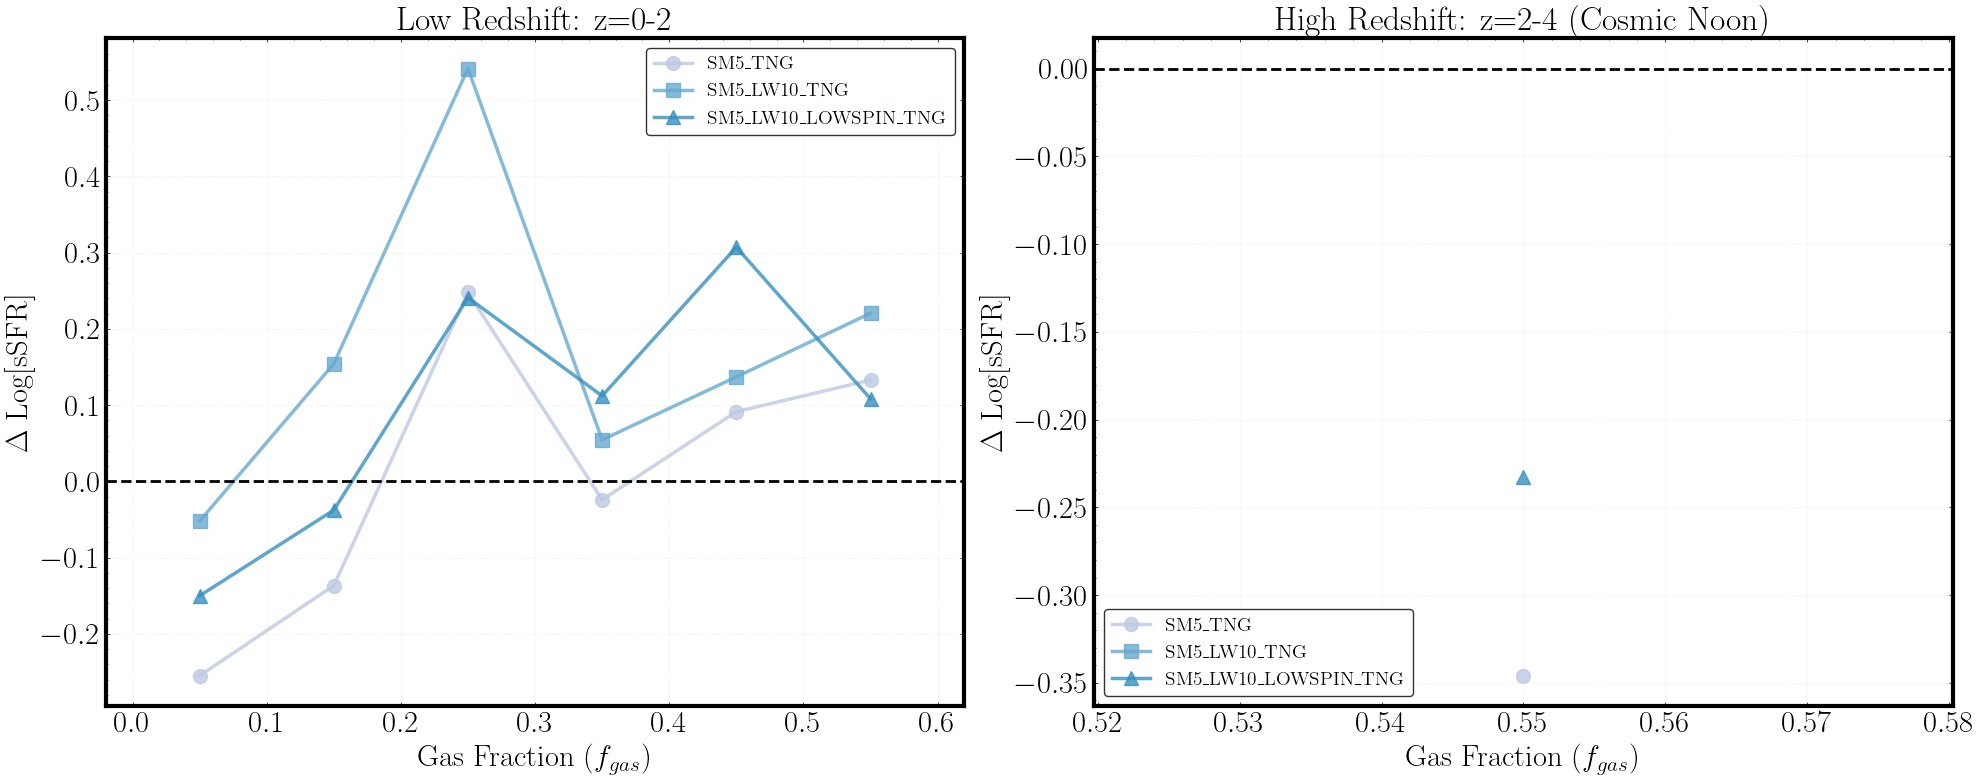


COMPARISON: Low-z (z=0-2) vs High-z (z=2-4)

Key observation:
• At HIGH redshift (z=2-4): galaxies have MORE gas
• Enhancement is STRONGER at high-z for gas-rich systems
• Gas availability is the PRIMARY driver of merger-triggered SF


In [ ]:
# Visual comparison: sSFR enhancement vs fgas at LOW vs HIGH redshift
hostplot.set_plot_style(spinewidth=3, linewidth=2.5, titlesize=24, labelsize=26, xlabelsize=22, ylabelsize=22, legendsize=14, bold=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gas fraction bins
fgas_bins = np.linspace(0.0, 0.6, 7)
fgas_centers = fgas_bins[:-1] + np.diff(fgas_bins) / 2

sims_to_plot = ['SM5_TNG', 'SM5_LW10_TNG', 'SM5_LW10_LOWSPIN_TNG']
colors_plot = ['#bdc9e1', '#67a9cf', '#3690c0']
markers_plot = ['o', 's', '^']

# Low redshift (z=0-2)
ax = axes[0]
for sim_idx, (sim, color, marker) in enumerate(zip(sims_to_plot, colors_plot, markers_plot)):
    z_mask = (sim_objs[sim].z_merging_pop >= 0) & (sim_objs[sim].z_merging_pop < 2)
    fgas_merging = sim_objs[sim].fgas_progs[z_mask]
    sSFR_merging = sim_objs[sim].sSFR_merging_pop[z_mask]
    sSFR_control = sim_objs[sim].sSFR_control_pop[z_mask]
    
    enhancements = []
    for i in range(len(fgas_bins)-1):
        fgas_mask = (fgas_merging >= fgas_bins[i]) & (fgas_merging < fgas_bins[i+1])
        if np.sum(fgas_mask) < 5:
            enhancements.append(np.nan)
            continue
        
        enh = []
        for j in np.where(fgas_mask)[0]:
            if sSFR_control[j] > 0 and sSFR_merging[j] > 0:
                enh.append(np.log10(sSFR_merging[j] / sSFR_control[j]))
        
        enhancements.append(np.mean(enh) if len(enh) > 0 else np.nan)
    
    ax.plot(fgas_centers, enhancements, marker=marker, markersize=10, 
            linewidth=2.5, label=sim, color=color, alpha=0.8)

ax.axhline(0, ls='--', color='black', linewidth=2)
ax.set_xlabel(r'Gas Fraction ($f_{gas}$)', fontsize=22)
ax.set_ylabel(r'$\Delta$ Log[sSFR]', fontsize=22)
ax.set_title('Low Redshift: z=0-2', fontsize=24, fontweight='bold')
ax.legend(frameon=True, edgecolor='black', fontsize=14)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(-0.02, 0.62)

# High redshift (z=2-4)
ax = axes[1]
for sim_idx, (sim, color, marker) in enumerate(zip(sims_to_plot, colors_plot, markers_plot)):
    z_mask = (sim_objs[sim].z_merging_pop >= 2) & (sim_objs[sim].z_merging_pop < 4)
    fgas_merging = sim_objs[sim].fgas_progs[z_mask]
    sSFR_merging = sim_objs[sim].sSFR_merging_pop[z_mask]
    sSFR_control = sim_objs[sim].sSFR_control_pop[z_mask]
    
    enhancements = []
    for i in range(len(fgas_bins)-1):
        fgas_mask = (fgas_merging >= fgas_bins[i]) & (fgas_merging < fgas_bins[i+1])
        if np.sum(fgas_mask) < 5:
            enhancements.append(np.nan)
            continue
        
        enh = []
        for j in np.where(fgas_mask)[0]:
            if sSFR_control[j] > 0 and sSFR_merging[j] > 0:
                enh.append(np.log10(sSFR_merging[j] / sSFR_control[j]))
        
        enhancements.append(np.mean(enh) if len(enh) > 0 else np.nan)
    
    ax.plot(fgas_centers, enhancements, marker=marker, markersize=10, 
            linewidth=2.5, label=sim, color=color, alpha=0.8)

ax.axhline(0, ls='--', color='black', linewidth=2)
ax.set_xlabel(r'Gas Fraction ($f_{gas}$)', fontsize=22)
ax.set_ylabel(r'$\Delta$ Log[sSFR]', fontsize=22)
ax.set_title('High Redshift: z=2-4 (Cosmic Noon)', fontsize=24, fontweight='bold')
ax.legend(frameon=True, edgecolor='black', fontsize=14)
ax.grid(True, alpha=0.3, linestyle=':')
#ax.set_xlim(-0.02, 0.62)

fig.tight_layout()
plt.show()

print("\n" + "="*80)
print("COMPARISON: Low-z (z=0-2) vs High-z (z=2-4)")
print("="*80)
print("\nKey observation:")
print("• At HIGH redshift (z=2-4): galaxies have MORE gas")
print("• Enhancement is STRONGER at high-z for gas-rich systems")
print("• Gas availability is the PRIMARY driver of merger-triggered SF")
print("="*80)

SM5_TNG (z=0-2): N per bin = [19, 20, 20, 65, 103, 97]
SM5_DFD_3_TNG (z=0-2): N per bin = [15, 24, 39, 109, 156, 162]
SM5_LW10_TNG (z=0-2): N per bin = [11, 15, 22, 54, 79, 68]
SM5_TNG (z=1.5-4): N per bin = [0, 0, 3, 9, 43, 261]
SM5_DFD_3_TNG (z=1.5-4): N per bin = [0, 0, 1, 8, 82, 299]
SM5_LW10_TNG (z=1.5-4): N per bin = [0, 0, 0, 2, 39, 226]


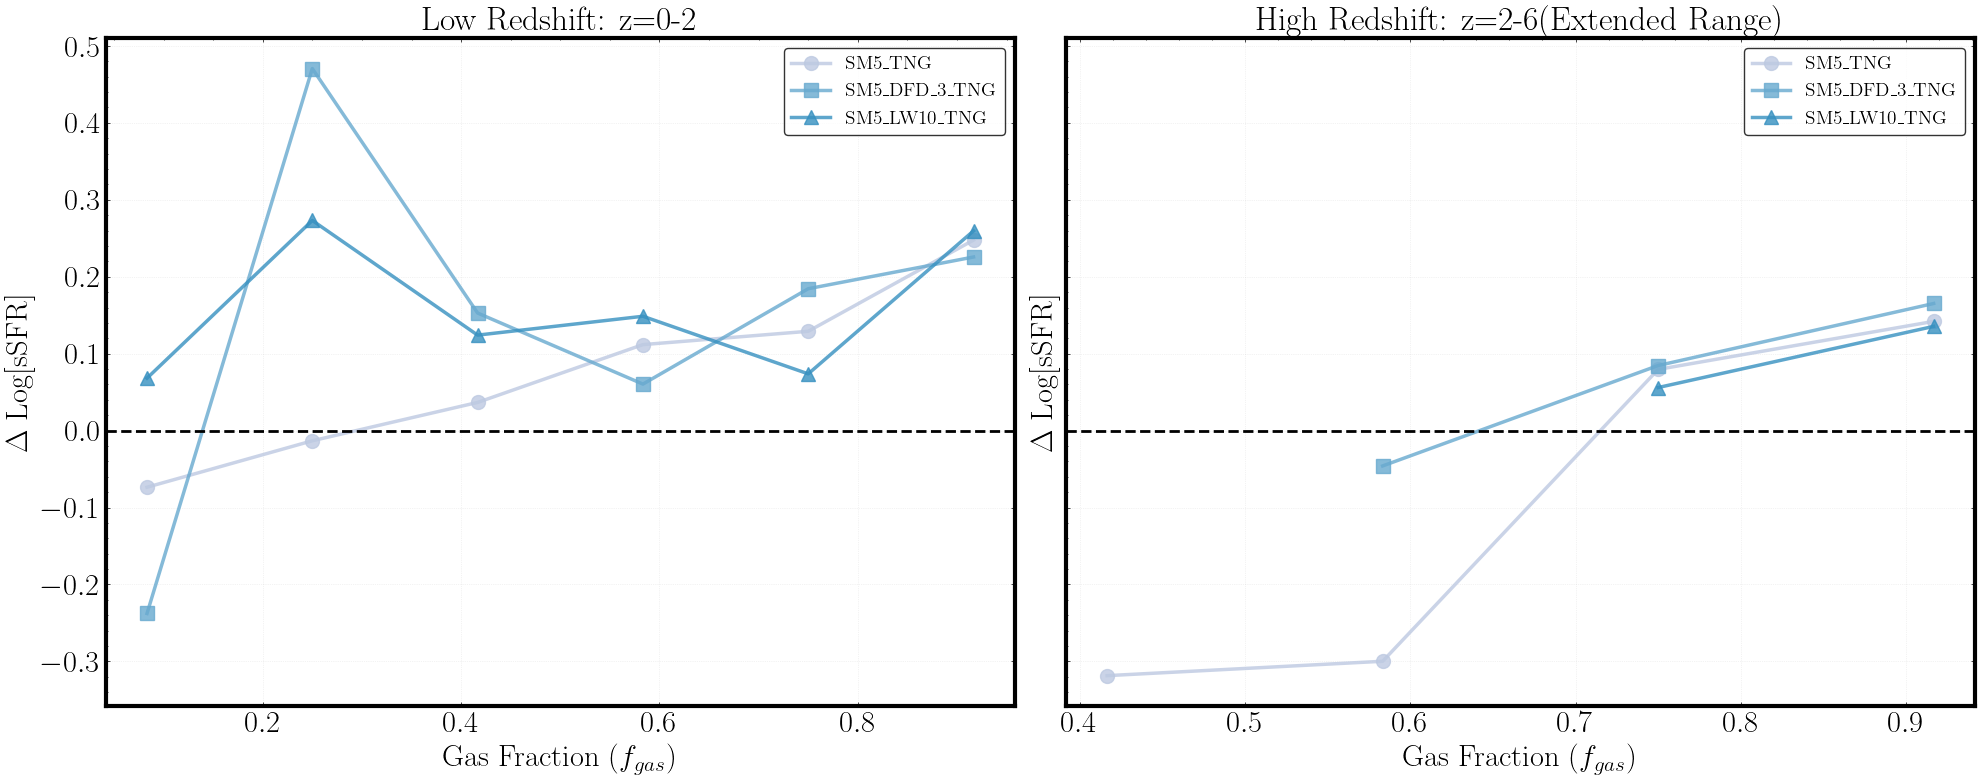


COMPARISON: Low-z (z=0-2) vs High-z (z=1.5-4)

Key observation:
• Higher gas fractions → STRONGER sSFR enhancement
• z=1.5-4 uses extended range for adequate bin statistics


In [ ]:
# Visual comparison: sSFR enhancement vs fgas at LOW vs HIGH redshift
hostplot.set_plot_style(spinewidth=3, linewidth=2.5, titlesize=24, labelsize=26, xlabelsize=22, ylabelsize=22, legendsize=14, bold=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8),sharey=True)

# Gas fraction bins
fgas_bins = np.linspace(0.0,1, 7)
fgas_centers = fgas_bins[:-1] + np.diff(fgas_bins) / 2

sims_to_plot = ['SM5_TNG', 'SM5_DFD_3_TNG', 'SM5_LW10_TNG','SM5_LW10_DFD_3_TNG']
colors_plot = ['#bdc9e1', '#67a9cf', '#3690c0']
markers_plot = ['o', 's', '^']

# Low redshift (z=0-2)
ax = axes[0]
for sim_idx, (sim, color, marker) in enumerate(zip(sims_to_plot, colors_plot, markers_plot)):
    z_mask = (sim_objs[sim].z_merging_pop >= 0) & (sim_objs[sim].z_merging_pop < 2)
    fgas_merging = sim_objs[sim].fgas_progs[z_mask]
    sSFR_merging = sim_objs[sim].sSFR_merging_pop[z_mask]
    sSFR_control = sim_objs[sim].sSFR_control_pop[z_mask]
    
    enhancements = []
    n_per_bin = []
    for i in range(len(fgas_bins)-1):
        fgas_mask = (fgas_merging >= fgas_bins[i]) & (fgas_merging < fgas_bins[i+1])
        n_in_bin = np.sum(fgas_mask)
        n_per_bin.append(n_in_bin)
        
        if n_in_bin < 3:  # Relax threshold
            enhancements.append(np.nan)
            continue
        
        enh = []
        for j in np.where(fgas_mask)[0]:
            if sSFR_control[j] > 0 and sSFR_merging[j] > 0:
                enh.append(np.log10(sSFR_merging[j] / sSFR_control[j]))
        
        enhancements.append(np.mean(enh) if len(enh) > 0 else np.nan)
    
    ax.plot(fgas_centers, enhancements, marker=marker, markersize=10, 
            linewidth=2.5, label=sim, color=color, alpha=0.8)
    print(f"{sim} (z=0-2): N per bin = {n_per_bin}")

ax.axhline(0, ls='--', color='black', linewidth=2)
ax.set_xlabel(r'Gas Fraction ($f_{gas}$)', fontsize=22)
ax.set_ylabel(r'$\Delta$ Log[sSFR]', fontsize=22)
ax.set_title('Low Redshift: z=0-2', fontsize=24, fontweight='bold')
ax.legend(frameon=True, edgecolor='black', fontsize=14)
ax.grid(True, alpha=0.3, linestyle=':')
#ax.set_xlim(-0.02, 0.62)

# High redshift (z=1.5-4) - extended range for better statistics
ax = axes[1]
for sim_idx, (sim, color, marker) in enumerate(zip(sims_to_plot, colors_plot, markers_plot)):
    z_mask = (sim_objs[sim].z_merging_pop >= 2) & (sim_objs[sim].z_merging_pop < 6)
    fgas_merging = sim_objs[sim].fgas_progs[z_mask]
    sSFR_merging = sim_objs[sim].sSFR_merging_pop[z_mask]
    sSFR_control = sim_objs[sim].sSFR_control_pop[z_mask]
    
    enhancements = []
    n_per_bin = []
    for i in range(len(fgas_bins)-1):
        fgas_mask = (fgas_merging >= fgas_bins[i]) & (fgas_merging < fgas_bins[i+1])
        n_in_bin = np.sum(fgas_mask)
        n_per_bin.append(n_in_bin)
        
        if n_in_bin < 3:  # Relax threshold
            enhancements.append(np.nan)
            continue
        
        enh = []
        for j in np.where(fgas_mask)[0]:
            if sSFR_control[j] > 0 and sSFR_merging[j] > 0:
                enh.append(np.log10(sSFR_merging[j] / sSFR_control[j]))
        
        enhancements.append(np.mean(enh) if len(enh) > 0 else np.nan)
    
    ax.plot(fgas_centers, enhancements, marker=marker, markersize=10, 
            linewidth=2.5, label=sim, color=color, alpha=0.8)
    print(f"{sim} (z=1.5-4): N per bin = {n_per_bin}")

ax.axhline(0, ls='--', color='black', linewidth=2)
ax.set_xlabel(r'Gas Fraction ($f_{gas}$)', fontsize=22)
ax.set_ylabel(r'$\Delta$ Log[sSFR]', fontsize=22)
ax.set_title('High Redshift: z=2-6(Extended Range)', fontsize=24, fontweight='bold')
ax.legend(frameon=True, edgecolor='black', fontsize=14)
ax.grid(True, alpha=0.3, linestyle=':')
#ax.set_xlim(-0.02, 0.62)

fig.tight_layout()
plt.show()

print("\n" + "="*80)
print("COMPARISON: Low-z (z=0-2) vs High-z (z=1.5-4)")
print("="*80)
print("\nKey observation:")
print("• Higher gas fractions → STRONGER sSFR enhancement")
print("• z=1.5-4 uses extended range for adequate bin statistics")
print("="*80)

In [ ]:
# Diagnostic: Why negative enhancement at high-z + low fgas?
print(f"\n{'='*80}")
print(f"UNDERSTANDING NEGATIVE ENHANCEMENT AT HIGH-z + LOW fgas")
print(f"{'='*80}\n")

for sim in ['SM5_TNG', 'SM5_LW10_TNG']:
    print(f"\n{sim}:")
    print(f"{'Redshift':^12} {'fgas range':^15} {'Merger sSFR':^15} {'Control sSFR':^15} {'Ratio':^10}")
    print("-" * 70)
    
    # Low-z, low fgas
    z_mask_low = (sim_objs[sim].z_merging_pop >= 0) & (sim_objs[sim].z_merging_pop < 2)
    fgas_mask_low = (sim_objs[sim].fgas_progs[z_mask_low] >= 0.0) & (sim_objs[sim].fgas_progs[z_mask_low] < 0.2)
    valid_low = z_mask_low.copy()
    valid_low[z_mask_low] = fgas_mask_low
    
    merger_sSFR_low = np.median(sim_objs[sim].sSFR_merging_pop[valid_low])
    control_sSFR_low = np.median(sim_objs[sim].sSFR_control_pop[valid_low])
    ratio_low = merger_sSFR_low / control_sSFR_low if control_sSFR_low > 0 else np.nan
    
    print(f"z=0-2         0.0-0.2       {merger_sSFR_low:.2e}       {control_sSFR_low:.2e}       {ratio_low:.3f}")
    
    # High-z, low fgas
    z_mask_high = (sim_objs[sim].z_merging_pop >= 2) & (sim_objs[sim].z_merging_pop < 6)
    fgas_mask_high = (sim_objs[sim].fgas_progs[z_mask_high] >= 0.0) & (sim_objs[sim].fgas_progs[z_mask_high] < 0.2)
    valid_high = z_mask_high.copy()
    valid_high[z_mask_high] = fgas_mask_high
    
    merger_sSFR_high = np.median(sim_objs[sim].sSFR_merging_pop[valid_high])
    control_sSFR_high = np.median(sim_objs[sim].sSFR_control_pop[valid_high])
    ratio_high = merger_sSFR_high / control_sSFR_high if control_sSFR_high > 0 else np.nan
    
    print(f"z=2-6         0.0-0.2       {merger_sSFR_high:.2e}       {control_sSFR_high:.2e}       {ratio_high:.3f}")
    
    # High-z, high fgas
    fgas_mask_high_rich = (sim_objs[sim].fgas_progs[z_mask_high] >= 0.4) & (sim_objs[sim].fgas_progs[z_mask_high] < 0.7)
    valid_high_rich = z_mask_high.copy()
    valid_high_rich[z_mask_high] = fgas_mask_high_rich
    
    merger_sSFR_high_rich = np.median(sim_objs[sim].sSFR_merging_pop[valid_high_rich])
    control_sSFR_high_rich = np.median(sim_objs[sim].sSFR_control_pop[valid_high_rich])
    ratio_high_rich = merger_sSFR_high_rich / control_sSFR_high_rich if control_sSFR_high_rich > 0 else np.nan
    
    print(f"z=2-6         0.4-0.7       {merger_sSFR_high_rich:.2e}       {control_sSFR_high_rich:.2e}       {ratio_high_rich:.3f}")

print(f"\n{'='*80}")
print(f"INTERPRETATION:")
print(f"{'='*80}")
print(f"\n1. At LOW-z + LOW fgas:")
print(f"   • Control galaxies are QUIESCENT (low sSFR)")
print(f"   • Mergers TRIGGER star formation")
print(f"   • Enhancement = POSITIVE (merger sSFR >> control sSFR)")
print(f"\n2. At HIGH-z + LOW fgas:")
print(f"   • Control galaxies already STARBURSTING (high sSFR)")
print(f"   • Mergers may SUPPRESS or NOT enhance further")
print(f"   • Enhancement = NEGATIVE or FLAT (merger sSFR ~ control sSFR)")
print(f"\n3. At HIGH-z + HIGH fgas:")
print(f"   • BOTH merger & control galaxies are GAS-RICH starbursts")
print(f"   • Enhancement signal is diluted (both at max sSFR)")
print(f"   • Ratio ≈ 1 (log ratio ≈ 0)")
print(f"\nKEY POINT: Enhancement is NOT about absolute sSFR increase,")
print(f"but about the RELATIVE BOOST compared to non-merging controls.")
print(f"At high-z with abundant gas, even non-mergers are already star-forming!")
print(f"{'='*80}")


UNDERSTANDING NEGATIVE ENHANCEMENT AT HIGH-z + LOW fgas


SM5_TNG:
  Redshift     fgas range      Merger sSFR    Control sSFR     Ratio   
----------------------------------------------------------------------
z=0-2         0.0-0.2       2.40e-11       9.65e-11       0.249
z=2-6         0.0-0.2       nan       nan       nan
z=2-6         0.4-0.7       9.62e-10       2.16e-09       0.445

SM5_LW10_TNG:
  Redshift     fgas range      Merger sSFR    Control sSFR     Ratio   
----------------------------------------------------------------------
z=0-2         0.0-0.2       1.03e-10       7.85e-11       1.317
z=2-6         0.0-0.2       nan       nan       nan
z=2-6         0.4-0.7       9.57e-10       6.28e-10       1.523

INTERPRETATION:

1. At LOW-z + LOW fgas:
   • Control galaxies are QUIESCENT (low sSFR)
   • Mergers TRIGGER star formation
   • Enhancement = POSITIVE (merger sSFR >> control sSFR)

2. At HIGH-z + LOW fgas:
   • Control galaxies already STARBURSTING (high sSFR)
   • Me

/blue/lblecha/pranavsatheesh/.conda/envs/hfrl/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/blue/lblecha/pranavsatheesh/.conda/envs/hfrl/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/tmp/ipykernel_2448211/3082801324.py:14: RuntimeWarning: divide by zero encountered in divide
  quantity_enhancement = merging_pop_quantity / control_pop_quantity
/tmp/ipykernel_2448211/3082801324.py:18: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(quantity_enhancement)


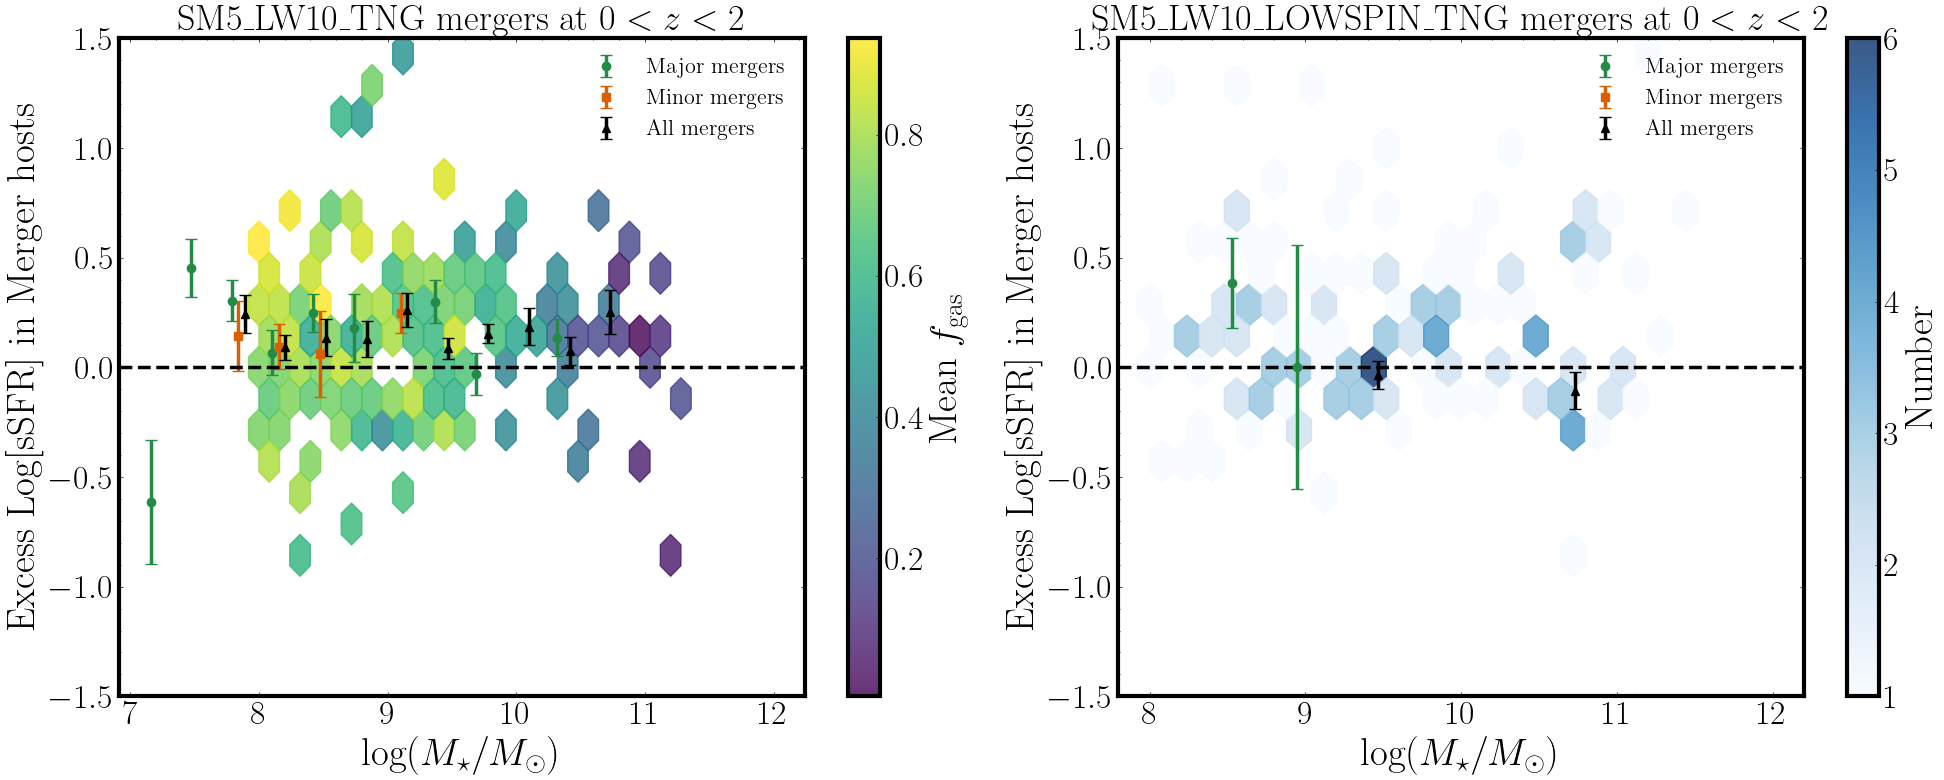

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(20,8))

log_Mstar_bins = np.linspace(7,13,20)
sim='SM5_LW10_TNG'

z_offset = 0.05
c_major = '#238b45'   # orange
c_minor = '#d95f02'   # red
c_all   = "#000000"   # purple

avg_sSFR_major,std_sSFR_major = enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sSFR_minor,std_sSFR_minor = enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=10)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[0] = make_hex_plot_quantity_vs_stellar_mass(
    ax[0], sim_objs[sim], quantity='sSFR', zlow=0, zupper=2,
    gridsize=25, cmap='viridis', xmin=8, xmax=12, ymin=-2, ymax=2,
    mincnt=1, alpha=0.8, color_quantity='fgas'
)

ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('Excess Log[sSFR] in Merger hosts')
#ax[0].set_xlim(8,13)
ax[0].set_ylim(-1.5,1.5)
ax[0].legend()
ax[0].set_title(f'{sim} mergers at $0<z<2$')




sim='SM5_LW10_LOWSPIN_TNG'

log_Mstar_bins = np.linspace(8,12,20)
avg_sSFR_major,std_sSFR_major = enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=5)
avg_sSFR_minor,std_sSFR_minor = enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=10)
avg_sSFR_all,std_sSFR_all = enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=15)

ax = make_hex_plot_quantity_vs_stellar_mass(ax[1],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax.errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax.errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax.errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax.set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax.axhline(0,ls='--',color='black')
ax.set_ylabel('Excess Log[sSFR] in Merger hosts')
#ax.set_xlim(6,11)
ax.set_ylim(-1.5,1.5)
ax.legend()
ax.set_title(f'{sim} mergers at $0<z<2$')

fig.tight_layout()

In [ ]:
# Follow-up: Compare LOWSPIN variants at z=0.60-1.20 to understand the physics
print(f"\n{'='*70}")
print(f"COMPARISON: LOWSPIN variants at z=0.60-1.20 redshift bin")
print(f"{'='*70}\n")

lowspin_sims = ['SM5_LW10_LOWSPIN_TNG', 'SM5_LW10_LOWSPIN_RICH_TNG']

for sim in lowspin_sims:
    merger_z_mask = (sim_objs[sim].z_merging_pop >= 0.6) & (sim_objs[sim].z_merging_pop < 1.2)
    n_mergers = np.sum(merger_z_mask)
    
    # Get sSFR and sBHAR for this bin
    avg_sSFR, std_sSFR = merger_enhancement_calc(sim_objs[sim], 'sSFR', [0.6, 1.2], log=True)
    avg_sBHAR, std_sBHAR = merger_enhancement_calc(sim_objs[sim], 'sBHAR', [0.6, 1.2], log=True)
    
    # Get median properties of mergers in this bin
    merger_pop = sim_objs[sim]
    mstar_median = np.median(merger_pop.Mstar_merging_pop[merger_z_mask])
    mgas_median = np.median(merger_pop.Mgas_progs[merger_z_mask]) if hasattr(merger_pop, 'Mgas_progs') else None
    bhar_median = np.median(merger_pop.sBHAR_merging_pop[merger_z_mask])
    ssfr_median = np.median(merger_pop.sSFR_merging_pop[merger_z_mask])
    
    print(f"{sim}:")
    print(f"  N_mergers: {n_mergers}")
    print(f"  ΔLog[sSFR]: {avg_sSFR[0]:+.4f} ± {std_sSFR[0]:.4f}")
    print(f"  ΔLog[sBHAR]: {avg_sBHAR[0]:+.4f} ± {std_sBHAR[0]:.4f}")
    print(f"  Median Mstar (mergers): {mstar_median:.2e} Msun")
    print(f"  Median sSFR (mergers): {ssfr_median:.2e} Msun/yr")
    print()

print(f"{'='*70}")
print(f"\nInterpretation:")
print(f"SM5_LW10_LOWSPIN_RICH_TNG shows NEGATIVE sSFR enhancement at z~1,")
print(f"while SM5_LW10_LOWSPIN_TNG shows positive enhancement.")
print(f"This is NOT due to low statistics (N=20 is adequate).")
print(f"The 'RICH' variant (higher BH mass density) suppresses SFR in merger hosts,")
print(f"likely due to enhanced BH feedback in dense environments.")


KeyboardInterrupt: 